# QuadTrees Test

This notebook contains a minimal implementation of the library in 2-D, for the sake of demonstrating with Quadtree Generation.

In [1]:
import numpy as np
from matplotlib import pyplot as plt
from finds.util import rejoin
from tqdm import trange

In [2]:
N = 5
BOUNDS = [10, 10]
L = 1
SIGMA = 4 * np.pi
U = SIGMA / (4 * np.pi * L ** 2) 

$$\mathbf{X} = (\mathbf{x}_c, \hat{n})$$

In [3]:
def generate_system(n):
    bounds = np.asarray(BOUNDS)
    positions = np.random.uniform(-bounds, bounds, size=(n, 2))
    # give them radial inward orientations
    orientations = -positions / np.linalg.norm(positions, axis=1, keepdims=True)
    return rejoin(positions, orientations)

def split(system):
    if system.ndim == 2:
        return system[:, :2], system[:, 2:]
    elif system.ndim == 1:
        return system[:2], system[2:]
    else:
        raise ValueError('bad system')

In [4]:
system = generate_system(N)
system

array([[-2.70272868,  3.62350255,  0.59788864, -0.80157917],
       [ 6.41835445, -0.31875711, -0.99876905,  0.04960224],
       [-1.60434369,  2.35444762,  0.56310642, -0.82638439],
       [-5.57380872,  8.96073546,  0.52818165, -0.84913141],
       [ 6.5624127 ,  8.01005799, -0.6337426 , -0.773544  ]])

In [5]:
ORIENTATION_LENGTH=1
def plot_system(system):
    positions, orientations = split(system)
    endpoints = positions + ORIENTATION_LENGTH * orientations

    plt.figure()
    plt.scatter(*positions.T, color='red')

    for p, e in zip(positions, endpoints):
        start = [p[0], e[0]]
        end = [p[1], e[1]]
        plt.plot(start, end, color='black')

    plt.axis('equal')
    plt.xlabel('X')
    plt.ylabel('Y')
    plt.show()

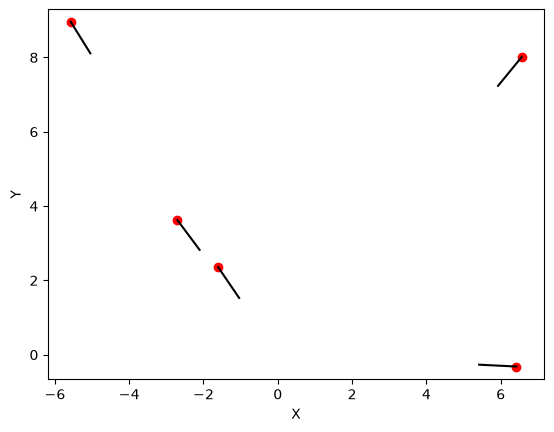

In [6]:
plot_system(system)

$$\mathbf{x}_f = \mathbf{x}_c + \vec{\delta}$$
$$\mathbf{x}_b = \mathbf{x}_c - \vec{\delta}$$
where
$$\vec{\delta} = \hat{n}\ell/2$$

In [7]:
def calc_feat_pos(mat):
    xc, nhat = split(mat)
    delta = nhat * L / 2
    return rejoin(xc + delta, xc - delta)

$$\mathbf{c}_{\alpha\beta} = \frac{\mathbf{r}_{\alpha\beta}}{r_{\alpha\beta}^3}$$
where
$$\mathbf{r}_{\alpha\beta} = \mathbf{x}_{\alpha,i} - \mathbf{x}_{\beta,j}$$

In [8]:
def calc_feat_inter(a, b):
    r = a - b
    return r / (np.linalg.norm(r) ** 3)

$$\mathbf{h}_{f,ij} = \mathbf{c}_{ff} - \mathbf{c}_{fb}$$
and
$$\mathbf{h}_{b,ij} = \mathbf{c}_{bf} - \mathbf{c}_{bb}$$

In [9]:
def calc_fish_interaction(fi, bi, fj, bj):
    ff = calc_feat_inter(fi, fj)
    fb = calc_feat_inter(fi, bj)
    bf = calc_feat_inter(bi, fj)
    bb = calc_feat_inter(bi, bj)
    return rejoin(ff - fb, bf - bb)

In [10]:
Q=4 # number of quadrants
class QuadTree:
    def __init__(self, center, side_len):
        self.kids=[None]*Q
        self.center = center
        self.side_len = side_len
        self.is_leaf = True
        self.cluster_size = 0
        self.cluster = np.zeros(4)
        self.data = None

    def calc_quad_idx(self, pos):
        qidx = 0
        for i in range(2):
            if pos[i] > self.center[i]:
                qidx += 2 ** i
        return qidx

    def calc_child_center(self, cqidx):
        offset_len = self.side_len / 4
        offset = np.zeros(2)
        for di in range(2):
            db = 2 ** di
            if cqidx & db:
                offset[di] = offset_len
            else:
                offset[di] = -offset_len
        return self.center + offset

    def insert_into_kids(self, data):
        qidx = self.calc_quad_idx(data[:2])
        if self.kids[qidx] is None:
            self.kids[qidx] = QuadTree(
                center = self.calc_child_center(qidx),
                side_len = self.side_len / 2
            )
        self.kids[qidx].insert_data(data)

    def insert_data(self, data):      
        if self.is_leaf and self.data is None:
            self.data = data
        elif self.is_leaf and self.data is not None:
            old_data = self.data
            self.is_leaf = False
            self.insert_into_kids(data)
            self.insert_into_kids(old_data)
        elif not self.is_leaf:
            self.insert_into_kids(data)

        self.cluster += data
        self.cluster_size += 1
        self.avg = self.cluster / self.cluster_size
    
    def calc_feat_pos(self):
        if self.avg is not None:
            fpos = calc_feat_pos(self.avg)
            self.xf, self.xb = fpos[:2], fpos[2:]

        for qidx in range(Q):
            if self.kids[qidx] is not None:
                self.kids[qidx].calc_feat_pos()

    def compute_interaction(self, xc, xf, xb, theta):
        if self.avg is None:
            return np.zeros(4)

        if self.is_leaf:
            if np.allclose(self.avg[:2], xc):
                return np.zeros(4)
            return calc_fish_interaction(xf, xb, self.xf, self.xb)

        dist = np.linalg.norm(xc - self.center)
        if np.isclose(dist, 0):
            phi = np.inf
        else:
            phi = self.side_len / dist

        if phi < theta:
            return calc_fish_interaction(xf, xb, self.xf, self.xb)
        else:
            total_int = np.zeros(4)
            for kid in self.kids:
                if kid is not None:
                    total_int += kid.compute_interaction(xc, xf, xb, theta)
            return total_int

In [11]:
def build_quadtree(system):
    pos, _ = split(system)
    mins = np.min(pos, axis=0)
    maxs = np.max(pos, axis=0)
    longest_distance = np.max(maxs - mins)

    # avoid boundary issues
    quadtree = QuadTree(
        center = (mins + maxs) / 2,
        side_len = longest_distance * 1.001
    )

    # add the fish to the tree
    for fish in system:
        quadtree.insert_data(fish)

    # compute the front and back positions
    quadtree.calc_feat_pos()

    return quadtree

In [12]:
def compute_interaction_barnes_hut(system, theta):
    n = system.shape[0]
    quadtree = build_quadtree(system)
    feat_pos = calc_feat_pos(system)
    interactions = np.zeros((n,4))

    for i in range(n):
        xci, nhati = split(system[i])
        xfi, xbi = split(feat_pos[i])
        interactions[i] = quadtree.compute_interaction(xci, xfi, xbi, theta)

    return interactions

In [13]:
def compute_interaction_pairwise(system):
    feat_pos = calc_feat_pos(system)
    n = system.shape[0]

    fpos_split = lambda idx: (feat_pos[idx, :2], feat_pos[idx, 2:])

    interactions = np.zeros((n,4))
    for i in range(n):
        fi, bi = fpos_split(i)
        interaction_total = np.zeros(4)
        
        for j in range(n):
            if i == j:
                continue
            fj, bj = fpos_split(j)
            interaction_total += calc_fish_interaction(fi, bi, fj, bj)
            
        interactions[i] = interaction_total

    return interactions

$$\mathbf{v}_{\alpha} = U \hat{n} + \frac{\sigma}{4\pi} \mathbf{h}_\alpha$$

In [14]:
def calc_feat_vel(system, theta):
    xc, nhat = split(system)
    internal = rejoin(U * nhat, U * nhat)
    interaction=None
    if np.isclose(theta, 0):
        interaction=compute_interaction_pairwise(system)
    else:
        interaction=compute_interaction_barnes_hut(system, theta)
    external = SIGMA / (4 * np.pi) * interaction
    return internal + external

$$\dot{\mathbf{X}} = (\dot{\mathbf{x}}_c, \dot{\mathbf{n}})$$
where
$$\dot{\mathbf{x}}_c = (\dot{\mathbf{x}}_f + \dot{\mathbf{x}}_b)/2$$
and
$$\dot{\mathbf{n}} = (\Delta \mathbf{v} + 2 \lambda \hat{n}) / \ell$$
where
$$\lambda = -\Delta \mathbf{v} \cdot \hat{n}$$
and
$$\Delta v = \dot{\mathbf{x}}_f - \dot{\mathbf{x}}_b$$

In [15]:
def compute_derivative(system, theta=0):
    xc, nhat = split(system)
    
    front_vel, back_vel = split(calc_feat_vel(system, theta))
    xcdot = (front_vel + back_vel) / 2

    dvel = front_vel - back_vel
    lagrange = -np.sum(dvel * nhat, axis=1)[:, np.newaxis] / 2
    ndot = (dvel + 2 * lagrange * nhat) / L

    return rejoin(xcdot, ndot)

In [16]:
print(compute_derivative(system, theta=0.1))

[[ 1.34797061e+00 -1.44576259e+00  3.13371578e-01  2.33740238e-01]
 [-9.92531647e-01  4.65142695e-02 -3.51725517e-05 -7.08219202e-04]
 [ 1.30423769e+00 -1.47331398e+00 -3.75446065e-01 -2.55832629e-01]
 [ 5.33308694e-01 -8.60756727e-01 -8.93264900e-04 -5.55633821e-04]
 [-6.31958883e-01 -7.71205481e-01 -8.42699140e-05  6.90399438e-05]]


$$
        \begin{align}
        \dot{\mathbf{X}}_1 &= f(\mathbf{X}_0)  \\
        \dot{\mathbf{X}}_2 &= f(\mathbf{X}_0 + \dot{\mathbf{X}}_1
          \delta t_{1/2}) \\
        \dot{\mathbf{X}}_3 &= f(\mathbf{X}_0 + \dot{\mathbf{X}}_2
          \delta t_{1/2}) \\
        \dot{\mathbf{X}}_4 &= f(\mathbf{X}_0 + \dot{\mathbf{X}}_3 \delta t)
        \end{align}
$$

and

$$
\dot{\mathbf{X}} \approx \frac{\dot{\mathbf{X}}_1 + 2
        \dot{\mathbf{X}}_2 + 2 \dot{\mathbf{X}}_3 + \dot{\mathbf{X}}_4}{6}
$$

for

$$\mathbf{X}_{\delta t} = \mathbf{X}_0 + \dot{\mathbf{X}} \delta t$$

In [17]:
def update_state_rk4(system, dt, theta=0):
    f = lambda X: compute_derivative(X, theta)

    X0 = system
    
    k1 = f(X0)
    k2 = f(X0 + k1 * dt / 2)
    k3 = f(X0 + k2 * dt / 2)
    k4 = f(X0 + k3 * dt)

    k = (k1 + 2 * k2 + 2 * k3 + k4) / 6
    Xt = X0 + k * dt

    x, n = split(Xt)
    
    return rejoin(x, n / np.linalg.norm(n, axis=1, keepdims=True))

In [18]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

def animate_system(system0, dt, tf, theta=0):
    fig, ax = plt.subplots()

    n_frames = int(tf / dt)
    
    positions, orientations = split(system0)
    endpoints = positions + ORIENTATION_LENGTH * orientations

    scatter = ax.scatter(*positions.T, color='red')

    lines = []
    for p, e in zip(positions, endpoints):
        start, end = [p[0], e[0]], [p[1], e[1]]
        line, = ax.plot(start, end, color='black')
        lines.append(line)

    ax.set_aspect('equal')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')

    system = system0.copy()

    def update(frame):
        nonlocal system

        system = update_state_rk4(system, dt, theta=theta)
        positions, orientations = split(system)
        endpoints = positions + ORIENTATION_LENGTH * orientations

        scatter.set_offsets(positions)

        ax.set_title(f"t={frame * dt:.2f}")
        for line, p, e in zip(lines, positions, endpoints):
            start=[p[0], e[0]]
            end=[p[1], e[1]]
            line.set_data(start, end)

        return [scatter, *lines]

    ani = FuncAnimation(fig, update, frames=n_frames, interval=20, blit=True)
    return HTML(ani.to_jshtml())

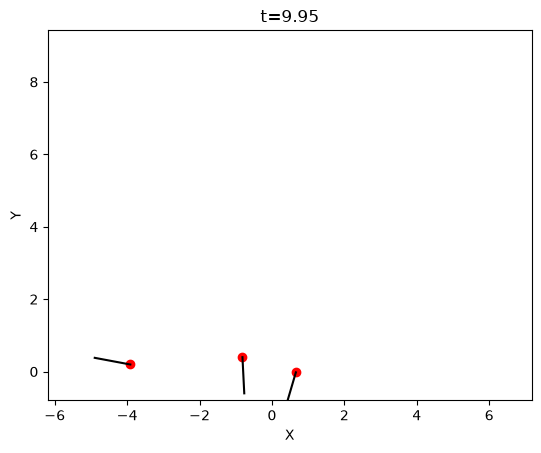

In [19]:
animate_system(system, dt=0.05, tf=10, theta=0.9)

## Timing

In [20]:
import time
def perform_time_test(n, theta, repeats=3):
    sys = generate_system(n)
    times = np.zeros(repeats)

    for i in range(repeats):
        start = time.perf_counter()
        compute_derivative(sys, theta)
        end = time.perf_counter()
        times[i] = end - start

    return np.mean(times)

In [27]:
from tqdm.notebook import tqdm
def generate_comparison_fig(min_log_n, max_log_n):
    lognvalues = np.arange(min_log_n, max_log_n + 1)
    lognvalues = np.flip(lognvalues)
    fig, ax = plt.subplots(figsize=(10, 6))

    # brute force
    brute_force_times = []
    for logn in tqdm(lognvalues, desc="Brute Force"):
        n = 2 ** logn
        t = perform_time_test(n, theta=0)
        brute_force_times.append(np.log2(t))

    slope_bf, intercept_bf = np.polyfit(lognvalues, brute_force_times, 1)
    k_bf = 2 ** intercept_bf

    ax.plot(
        lognvalues,
        brute_force_times,
        label=f"Brute Force (k={k_bf:.2e}, slope={slope_bf:.2f})",
        linewidth=3
    )

    # barnes-hut
    thetas = np.arange(0.25, 1.0, step=0.25)
    for theta in tqdm(thetas, desc="Barnes-Hut"):

        bh_times = []
        for logn in tqdm(lognvalues, leave=False, desc=f'Theta={theta:.2f}'):
            n = 2 ** logn
            t = perform_time_test(n, theta)
            bh_times.append(np.log2(t))

        slope_bh, intercept_bh = np.polyfit(lognvalues, bh_times, 1)
        k_bh = 2 ** intercept_bh

        ax.plot(
            lognvalues,
            bh_times,
            label=rf"Barnes-Hut ($\theta={theta:.2f}$, k={k_bh:.2e}, slope={slope_bh:.2f})",
            linewidth=2
        )

    ax.set_xlabel(r"$\log_2 N$")
    ax.set_ylabel(r"$\log_2$ runtime (s)")
    ax.set_title("Barnes–Hut vs Brute Force (2D)")
    ax.grid(True)
    ax.legend()

    plt.plot()

Brute Force:   0%|          | 0/9 [00:00<?, ?it/s]

Barnes-Hut:   0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/9 [00:00<?, ?it/s]

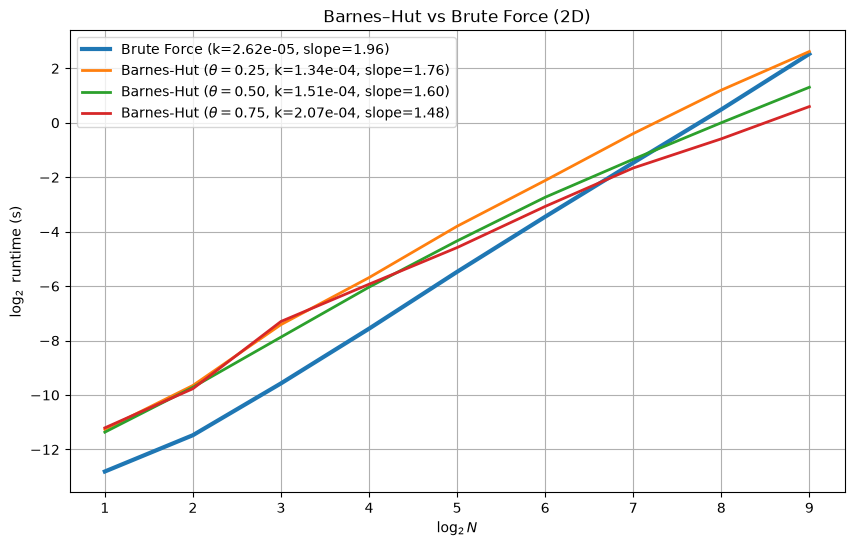

In [28]:
generate_comparison_fig(1, 9)